<a href="https://colab.research.google.com/github/Harss3/Pyhton-Exercise/blob/main/%5BClustering%5D_Submission_Akhir_BMLP_Your_Name.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [103]:
df = pd.read_csv('/content/drive/ My Drive/Collabs ML/spending.csv')
df.head()

,Customer ID,Category,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,CUST_0159,Groceries,Milk,1,1.28,1.28,Debit Card,Mobile App,2024-11-13
1,CUST_0017,Friend Activities,Dinner with Friends,2,74.69,149.39,Debit Card,In-store,2023-05-04
2,CUST_0094,Housing and Utilities,Water Bill,1,76.06,76.06,Digital Wallet,Mobile App,2023-12-16
3,CUST_0162,Fitness,Yoga Class,5,11.24,56.18,Cash,In-store,2024-01-28
4,CUST_0129,Gifts,Flowers,3,43.71,131.12,Debit Card,In-store,2023-07-28


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer ID       10000 non-null  object 
 1   Category          10000 non-null  object 
 2   Item              10000 non-null  object 
 3   Quantity          10000 non-null  int64  
 4   Price Per Unit    10000 non-null  float64
 5   Total Spent       10000 non-null  float64
 6   Payment Method    10000 non-null  object 
 7   Location          10000 non-null  object 
 8   Transaction Date  10000 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 703.3+ KB


In [105]:
# mengidentifikasi nilai kosong pada dataset
print('Jumlah nilai kosong pada dataset: ', df.isnull().sum())

# mengidentifikasi duplikasi baris pada dataset
print('\n')
print('Jumlah duplikasi pada baris: ', df.duplicated().sum())

Jumlah nilai kosong pada dataset:  Customer ID         0
Category            0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


Jumlah duplikasi pada baris:  0


In [106]:
# mengidentifikasi kategori berbeda pada kolom Category, Quantity, Payment Method, dan Location

print('Kategori pada kolom Category: ', df['Category'].unique())
print('Kategori pada kolom Quantity: ', df['Quantity'].unique())
print('Kategori pada kolom Payment Method: ', df['Payment Method'].unique())
print('Kategori pada kolom Location: ', df['Location'].unique())

Kategori pada kolom Category:  ['Groceries' 'Friend Activities' 'Housing and Utilities' 'Fitness' 'Gifts'
 'Transportation' 'Travel' 'Personal Hygiene' 'Hobbies' 'Shopping'
 'Medical/Dental' 'Food' 'Subscriptions']
Kategori pada kolom Quantity:  [1 2 5 3 4]
Kategori pada kolom Payment Method:  ['Debit Card' 'Digital Wallet' 'Cash' 'Credit Card']
Kategori pada kolom Location:  ['Mobile App' 'In-store' 'Online']


Berdasarkan dataset di atas, jenis kategori yang kita peroleh dari kolom kategori berjumlah 13 yang terdiri dari Groceries, Friend Activities, Housing and Utilities, Fitness, Gifts, Transportation, Travel, Personal Hygiene, Hobbies, Shopping, Medical/Dental, Food, dan Subscriptions. Kita akan mereduksi jenis kategori ini menjadi 5 jenis yang dikelompokkan sebagai berikut:

Shopping -> Groceries, Shopping, Food

Hobbies -> Fitness, Travel, Hobbies

Home -> Housing and Utilities, Subscriptions

Medical -> Personal Hygiene, Medical/Dental

Personal -> Gifts, Friend Activities, Transportation

In [107]:
# mereduksi jenis kategori pada kolom Category menjadi 5 jenis
Hobbies = {'Fitness', 'Travel', 'Hobbies'}
Shopping = {'Groceries', 'Shopping', 'Food'}
Home = {'Housing and Utilities', 'Subscriptions'}
Medical = {'Personal Hygiene', 'Medical/Dental'}
Personal = {'Gifts', 'Friend Activities', 'Transportation'}

df['Category'].replace({items: 'Shopping' for items in Shopping}, inplace=True)
df['Category'].replace({items: 'Hobbies' for items in Hobbies}, inplace=True)
df['Category'].replace({items: 'Home' for items in Home}, inplace=True)
df['Category'].replace({items: 'Medical' for items in Medical}, inplace=True)
df['Category'].replace({items: 'Personal' for items in Personal}, inplace=True)
print('Kategori pada kolom Category: ', df['Category'].unique())

Kategori pada kolom Category:  ['Shopping' 'Personal' 'Home' 'Hobbies' 'Medical']


<ipython-input-107-3401a431302c>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Category'].replace({items: 'Shopping' for items in Shopping}, inplace=True)


In [108]:
# merubah format kolom Transaction Date menjadi format datetime
import datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
dates = []
for i in df['Transaction Date']:
  dates.append(i.date())
print('Recent Transaction, ', max(dates))
print('Oldest Transaction, ', min(dates))

Recent Transaction,  2025-01-13
Oldest Transaction,  2023-01-01


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Customer ID       10000 non-null  object        
 1   Category          10000 non-null  object        
 2   Item              10000 non-null  object        
 3   Quantity          10000 non-null  int64         
 4   Price Per Unit    10000 non-null  float64       
 5   Total Spent       10000 non-null  float64       
 6   Payment Method    10000 non-null  object        
 7   Location          10000 non-null  object        
 8   Transaction Date  10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 703.3+ KB


Berdasarkan informasi di atas, format data pada kolom Transaction Date telah berubah menjadi format datetime

In [110]:
# untuk memudahkan analisa data, format tanggal pada Transaction Date diubah terlebih dahulu ke tahun
df['Transaction Date'] = df['Transaction Date'].dt.year
df.head()

,Customer ID,Category,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,CUST_0159,Shopping,Milk,1,1.28,1.28,Debit Card,Mobile App,2024
1,CUST_0017,Personal,Dinner with Friends,2,74.69,149.39,Debit Card,In-store,2023
2,CUST_0094,Home,Water Bill,1,76.06,76.06,Digital Wallet,Mobile App,2023
3,CUST_0162,Hobbies,Yoga Class,5,11.24,56.18,Cash,In-store,2024
4,CUST_0129,Personal,Flowers,3,43.71,131.12,Debit Card,In-store,2023


In [111]:
# mengubah nama kolom Transaction Date menjadi Year
df.rename(columns={'Transaction Date': 'Year'}, inplace=True)
print('Kategori tahun pada kolom Year: ', df['Year'].unique())
df.head()

Kategori tahun pada kolom Year:  [2024 2023 2025]


,Customer ID,Category,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Year
0,CUST_0159,Shopping,Milk,1,1.28,1.28,Debit Card,Mobile App,2024
1,CUST_0017,Personal,Dinner with Friends,2,74.69,149.39,Debit Card,In-store,2023
2,CUST_0094,Home,Water Bill,1,76.06,76.06,Digital Wallet,Mobile App,2023
3,CUST_0162,Hobbies,Yoga Class,5,11.24,56.18,Cash,In-store,2024
4,CUST_0129,Personal,Flowers,3,43.71,131.12,Debit Card,In-store,2023


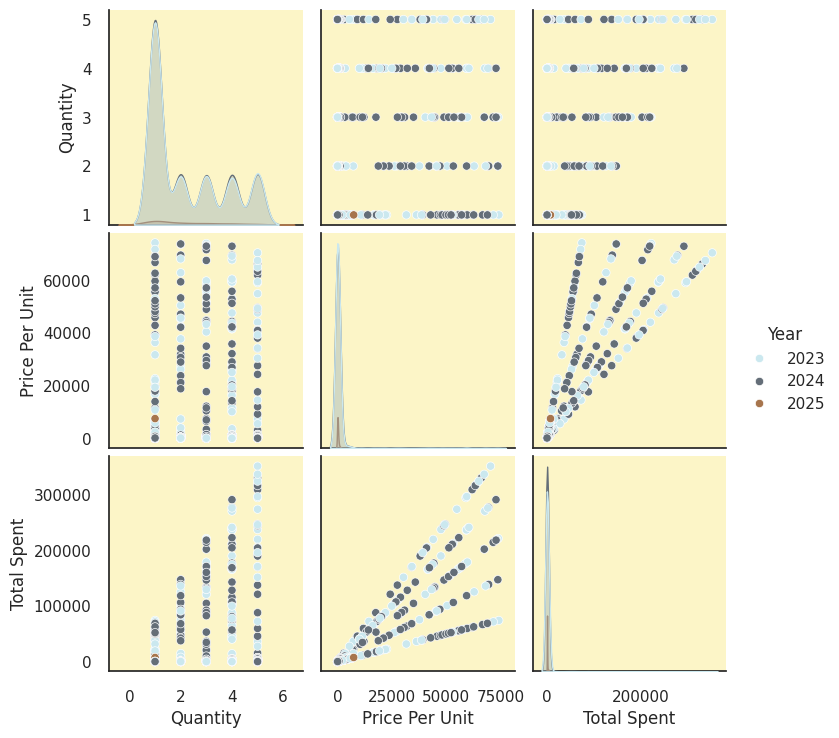

In [112]:
# menampilkan korelasi pada fitur numerik
pair = ['Quantity', 'Price Per Unit', 'Total Spent', 'Year']
palet = ['#CBE8EF', '#646E78', '#A7754D']
sb.set_theme(rc={'axes.facecolor': '#FCF5C7'}, style='white')
sb.pairplot(data=df[pair], hue='Year', palette=palet)
plt.show()

Berdasarkan grafik di atas kita dapat menyaksikan bahwa fitur Total Spent dan Price Per Unit memiliki hubungan linear

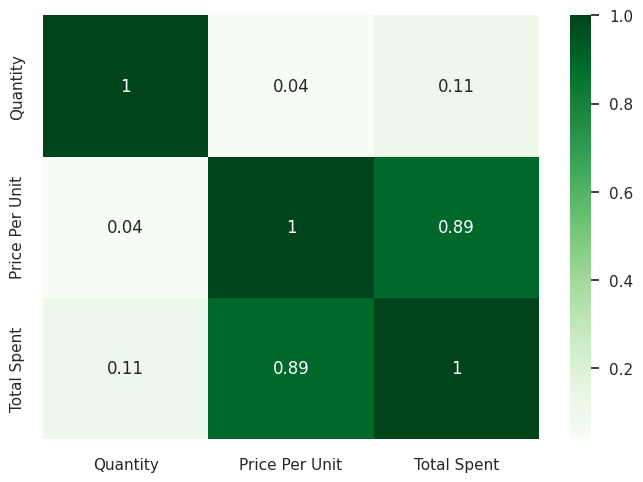

In [113]:
# menemukan korelasi dengan heatmap
num = ['Quantity', 'Price Per Unit', 'Total Spent']
corr = df[num].corr()
sb.heatmap(data=corr, annot=True, cmap='Greens')
plt.show()

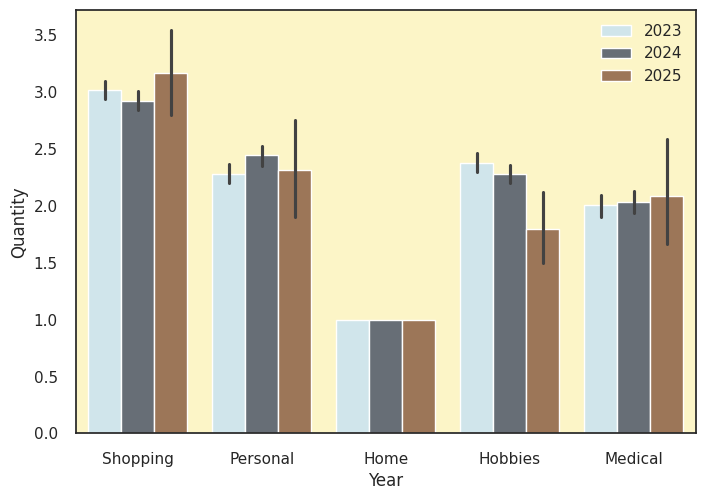

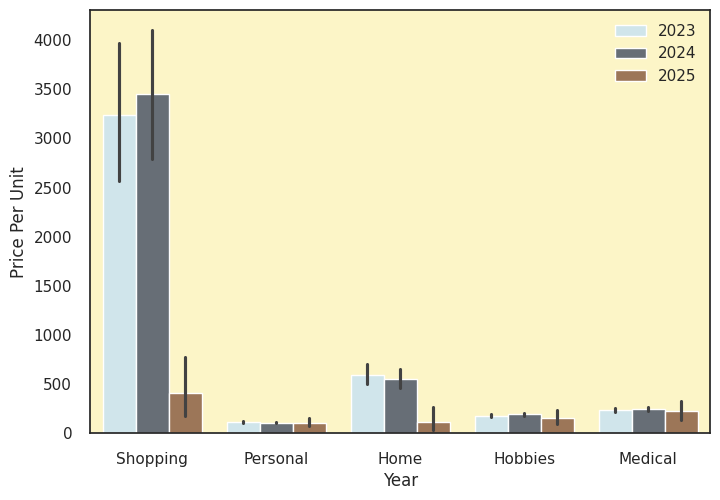

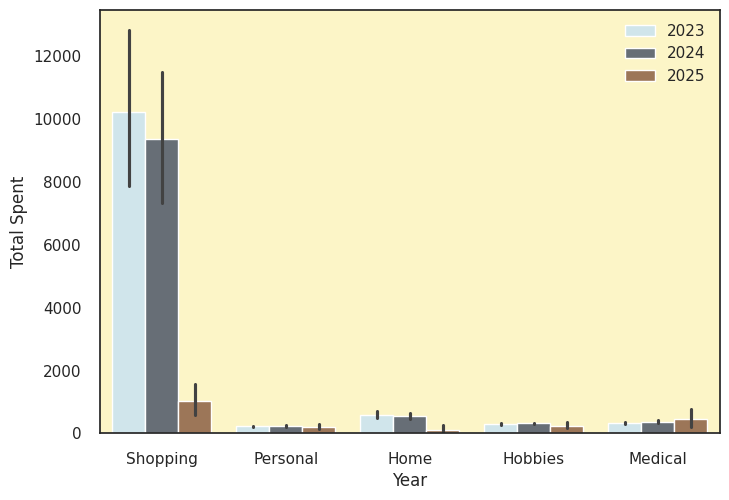

In [114]:
# distribusi fitur numerik berdasarkan kolom Category pada tiap tahun
numerikal = ['Quantity', 'Price Per Unit', 'Total Spent']
for i, column in enumerate(numerikal, 1):
  sb.barplot(data=df, x='Category', y=column, hue='Year', palette=palet)
  plt.xlabel('Year')
  plt.ylabel(column)
  plt.legend()
  plt.show()

In [115]:
# distribusi fitur kategorikal berdasarkan kolom Category pada tiap tahun
# mengetahui jumlah maksimum penggunaan Payment Method pada tiap Category di tiap tahun
payment_perYear = df.groupby(['Category', 'Year', 'Payment Method']).size().reset_index(name='Count')
payment_perYear = payment_perYear.loc[payment_perYear.groupby(['Category','Year'])['Count'].idxmax()].reset_index(drop=True)
payment_perYear.head()

,Category,Year,Payment Method,Count
0,Hobbies,2023,Digital Wallet,290
1,Hobbies,2024,Cash,314
2,Hobbies,2025,Digital Wallet,14
3,Home,2023,Cash,195
4,Home,2024,Digital Wallet,207


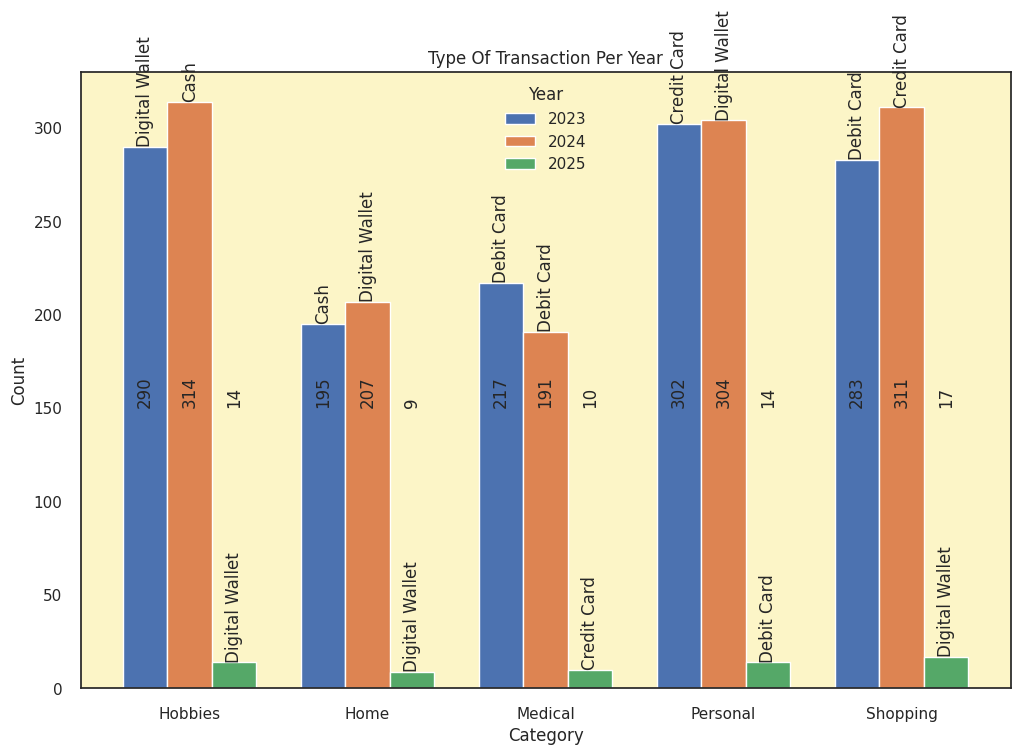

In [116]:
# grafik barplot untuk mengetahui jumlah maksimum penggunaan Payment Method pada tiap Category di tiap tahun
import numpy as np
category = payment_perYear['Category'].unique()
years = payment_perYear['Year'].unique()
distance = np.arange(len(category))
width = 0.25
fig, ax = plt.subplots(figsize=(12,8))
for i, year in enumerate(years):
    offset = i * width
    subset = payment_perYear[payment_perYear['Year'] == year]
    bars = ax.bar(distance + offset, subset['Count'], width, label=str(year))
    for bar, label in zip(bars, subset['Payment Method']):
      height = bar.get_height()
      ax.text(bar.get_x() + bar.get_width() / 2, height, label, ha='center', va='bottom', rotation=90)
    for bar, label in zip(bars, subset['Count']):
      ax.text(bar.get_x() + bar.get_width() / 2, 150, label, ha='center', va='bottom', rotation=90)
plt.legend(title='Year',loc='upper center')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Type Of Transaction Per Year')
plt.xticks(distance + width, category)
plt.show()

In [117]:
# mengelompokkan lokasi transaksi pada tiap kategori di tiap tahun
# menemukan nilai maksimum dari jenis transaksi di tiap kategori pada tiap tahun
transaction = df.groupby(['Category', 'Year', 'Location']).size().reset_index(name='Count')
transaction = transaction.loc[transaction.groupby(['Category', 'Year'])['Count'].idxmax()].reset_index(drop=True)
transaction.head()

,Category,Year,Location,Count
0,Hobbies,2023,In-store,381
1,Hobbies,2024,Mobile App,383
2,Hobbies,2025,Online,14
3,Home,2023,In-store,249
4,Home,2024,In-store,261


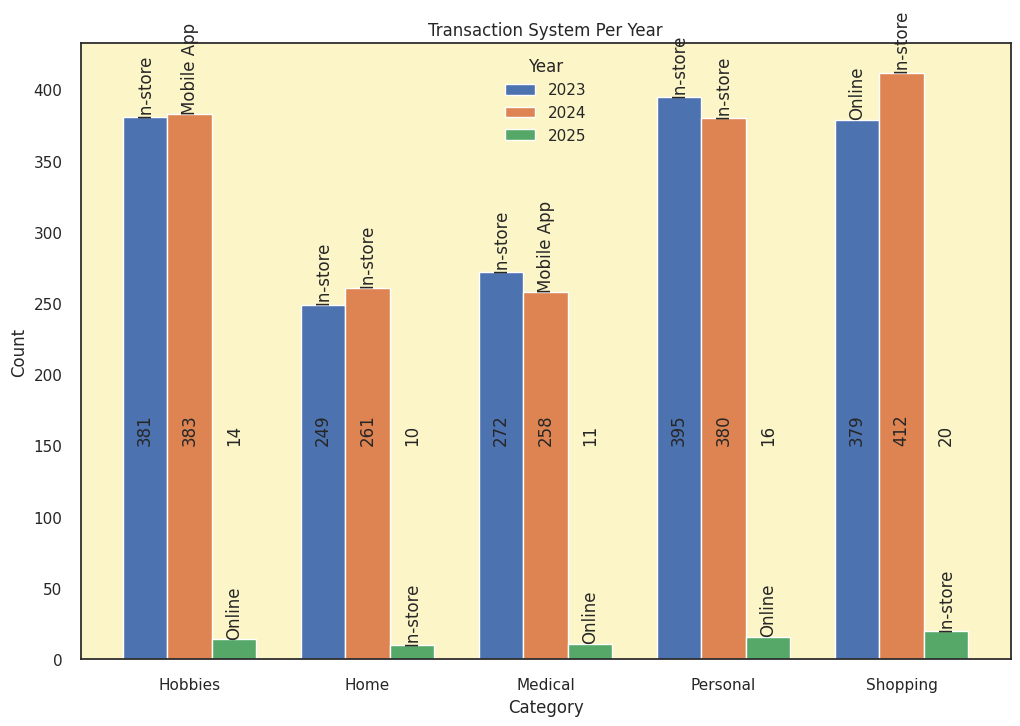

In [118]:
fig, ax = plt.subplots(figsize=(12,8))
for i, year in enumerate(years):
    offset = i * width
    subset = transaction[transaction['Year'] == year]
    bars = ax.bar(distance + offset, subset['Count'], width, label=str(year))
    for bar, label in zip(bars, subset['Location']):
      height = bar.get_height()
      ax.text(bar.get_x() + bar.get_width() / 2, height, label, ha='center', va='bottom', rotation=90)
    for bar, label in zip(bars, subset['Count']):
      ax.text(bar.get_x() + bar.get_width() / 2, 150, label, ha='center', va='bottom', rotation=90)
plt.legend(title='Year', loc='upper center')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Transaction System Per Year')
plt.xticks(distance + width, category)
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [119]:
new_df = pd.read_csv('/content/drive/ My Drive/Collabs ML/spending.csv')
new_df.head()

,Customer ID,Category,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,CUST_0159,Groceries,Milk,1,1.28,1.28,Debit Card,Mobile App,2024-11-13
1,CUST_0017,Friend Activities,Dinner with Friends,2,74.69,149.39,Debit Card,In-store,2023-05-04
2,CUST_0094,Housing and Utilities,Water Bill,1,76.06,76.06,Digital Wallet,Mobile App,2023-12-16
3,CUST_0162,Fitness,Yoga Class,5,11.24,56.18,Cash,In-store,2024-01-28
4,CUST_0129,Gifts,Flowers,3,43.71,131.12,Debit Card,In-store,2023-07-28


In [120]:
# mendeteksi nilai nol pada dataset
print('Jumlah nilai nol pada dataset:\n', new_df.isnull().sum())
print('\n')

# mendeteksi duplikasi baris pada dataset
print('Jumlah duplikasi pada baris: ', new_df.duplicated().sum())

Jumlah nilai nol pada dataset:
 Customer ID         0
Category            0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


Jumlah duplikasi pada baris:  0


In [121]:
# menghapus kolom Customer ID dan Item karena tidak dibutuhkan
df = df.drop(columns=['Customer ID', 'Item'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        10000 non-null  object 
 1   Quantity        10000 non-null  int64  
 2   Price Per Unit  10000 non-null  float64
 3   Total Spent     10000 non-null  float64
 4   Payment Method  10000 non-null  object 
 5   Location        10000 non-null  object 
 6   Year            10000 non-null  int32  
dtypes: float64(2), int32(1), int64(1), object(3)
memory usage: 507.9+ KB


In [122]:
# mengubah kolom Year pada dataset dengan format Days
df['Year'] = new_df['Transaction Date']

days = []
day1 = max(dates)
for i in dates:
  delta = day1 - i
  days.append(delta)
df['Year'] = days
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# mengubah nama kolom Year menjadi Days
df.rename(columns={'Year': 'Days'}, inplace=True)
df.head()

,Category,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Days
0,Shopping,1,1.28,1.28,Debit Card,Mobile App,5270400000000000
1,Personal,2,74.69,149.39,Debit Card,In-store,53568000000000000
2,Home,1,76.06,76.06,Digital Wallet,Mobile App,34041600000000000
3,Hobbies,5,11.24,56.18,Cash,In-store,30326400000000000
4,Personal,3,43.71,131.12,Debit Card,In-store,46224000000000000


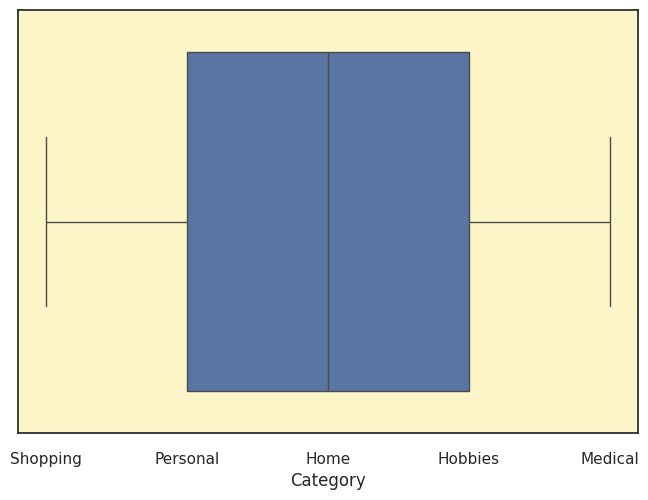

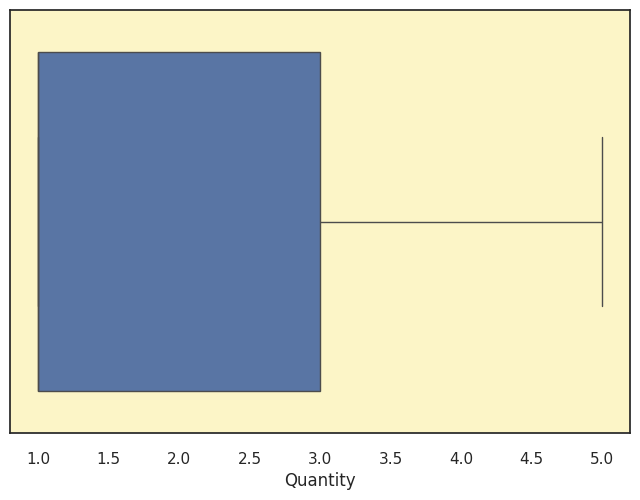

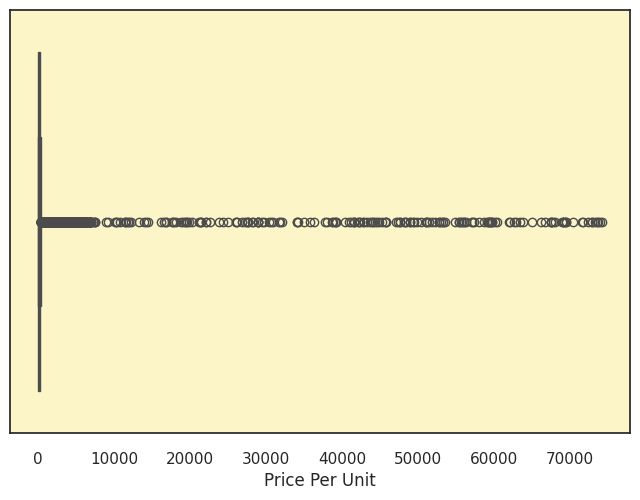

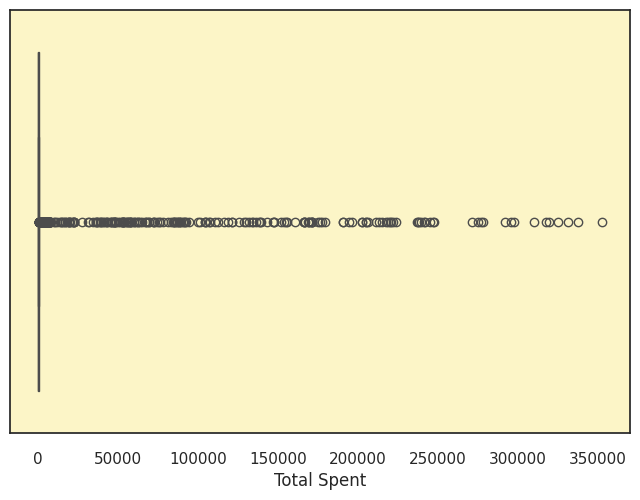

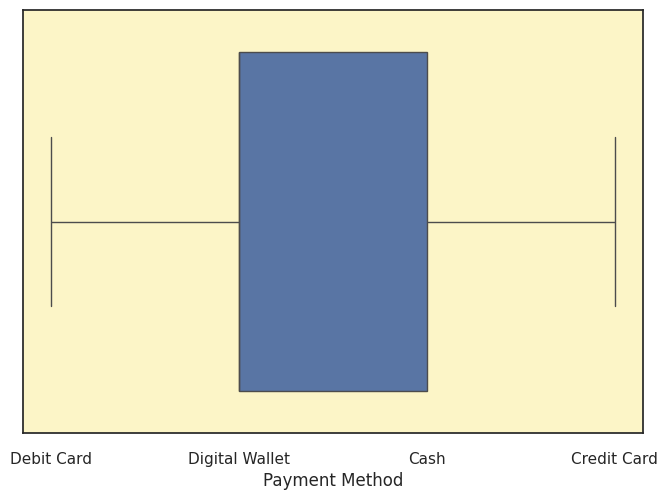

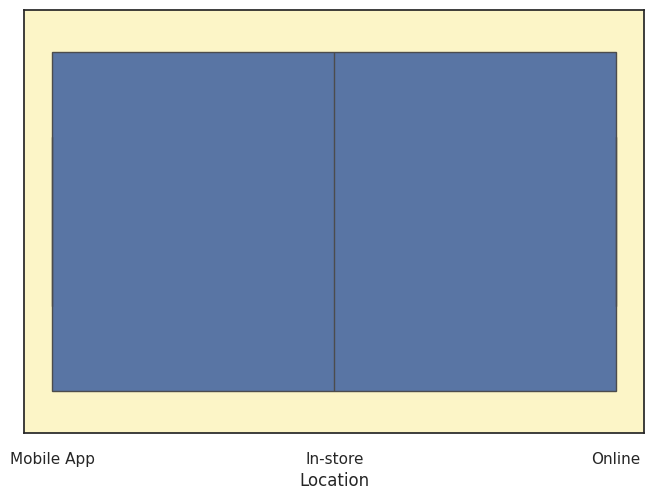

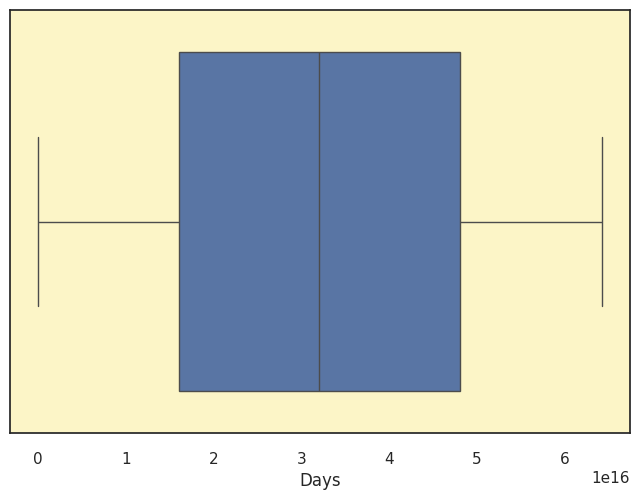

In [123]:
# mendeteksi outlier pada dataset
for i in df.columns:
  sb.boxplot(data=df, x=i, orient='h')
  plt.show()

Grafik menunjukkan bahwa mayoritas fitur dalam posisi moderat dari outlier

In [124]:
# mengambil dataset sebelum encoding
df_before = df.copy()

# mengetahui deskripsi dari dataset
df.describe()

,Quantity,Price Per Unit,Total Spent,Days
count,10000.000000,10000.000000,10000.000000,1.000000e+04
mean,2.237200,969.957948,2534.750890,3.196794e+16
std,1.481133,6104.403843,19676.741772,1.850316e+16
min,1.000000,1.000000,1.110000,0.000000e+00
25%,1.000000,12.960000,25.957500,1.607040e+16
50%,1.000000,51.860000,88.115000,3.196800e+16
75%,3.000000,177.587500,336.375000,4.803840e+16
max,5.000000,74246.460000,352230.760000,6.419520e+16


In [125]:
# mengubah fitur kategorikal menjadi numerik dengan label encoder
label = LabelEncoder()
df['Category'] = label.fit_transform(df['Category'])
df['Payment Method'] = label.fit_transform(df['Payment Method'])
df['Location'] = label.fit_transform(df['Location'])
df.describe()

,Category,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,1.000000e+04
mean,2.094900,2.237200,969.957948,2534.750890,1.510500,0.99200,3.196794e+16
std,1.495031,1.481133,6104.403843,19676.741772,1.121435,0.81817,1.850316e+16
min,0.000000,1.000000,1.000000,1.110000,0.000000,0.00000,0.000000e+00
25%,1.000000,1.000000,12.960000,25.957500,1.000000,0.00000,1.607040e+16
50%,2.000000,1.000000,51.860000,88.115000,2.000000,1.00000,3.196800e+16
75%,3.000000,3.000000,177.587500,336.375000,3.000000,2.00000,4.803840e+16
max,4.000000,5.000000,74246.460000,352230.760000,3.000000,2.00000,6.419520e+16


In [126]:
# standardisasi semua fitur yang terdapat pada dataset menggunakan standart scaler
scale = StandardScaler()
df_standart = scale.fit_transform(df)
df_standart = pd.DataFrame(df_standart, columns=df.columns)
df_standart.head()

,Category,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Days
0,1.274352,-0.835348,-0.158693,-0.128761,0.436516,0.009778,-1.442936
1,0.605436,-0.160156,-0.146667,-0.121233,0.436516,-1.212522,1.167430
2,-0.732396,-0.835348,-0.146442,-0.124960,1.328276,0.009778,0.112076
3,-1.401312,1.865422,-0.157061,-0.125971,-1.347003,-1.212522,-0.088721
4,0.605436,0.515037,-0.151742,-0.122162,0.436516,-1.212522,0.770505


# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [127]:
# menggunakan algoritma Agglomerative Clustering
ac = AgglomerativeClustering(n_clusters=3)
y_ac = ac.fit_predict(df_standart)
y_ac

array([0, 0, 0, ..., 0, 0, 0])

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

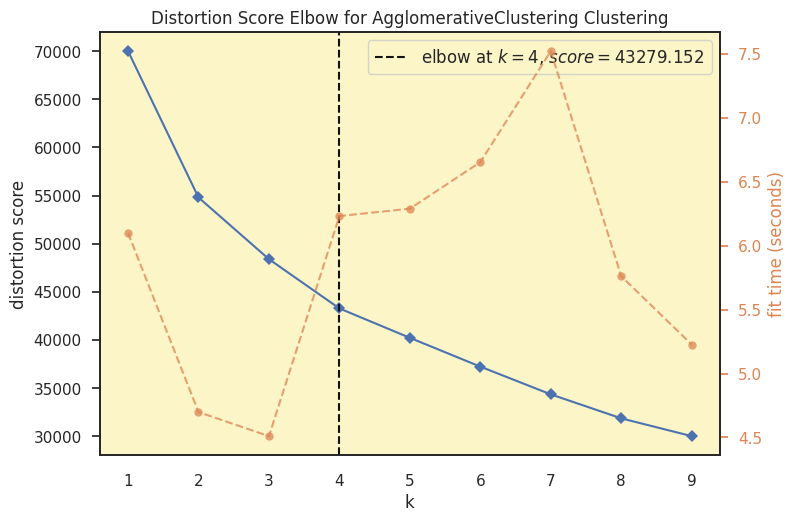

<Axes: title={'center': 'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [128]:
# menggunakan K-Elbow untuk menentukan jumlah n-cluster
ke = KElbowVisualizer(AgglomerativeClustering(), k=(1,10))
ke.fit(df_standart)
ke.show()

In [129]:
# mengevaluasi model dengan silhouette score sebelum seleksi fitur
score_ac = silhouette_score(df_standart, y_ac)
print('Skor model clustering sebelum seleksi fitur: ', score_ac)

Skor model clustering sebelum seleksi fitur:  0.16275182493580415


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [130]:
# optimasi model dengan fitur selection menggunakan PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(df_standart)
x_pca

array([[-0.03175997,  0.31320002],
       [-0.07549132,  0.25481287],
       [-0.50223521, -0.99793574],
       ...,
       [ 0.06257398,  0.20383647],
       [-0.1765981 , -0.12243801],
       [-0.4927983 , -0.99453567]])

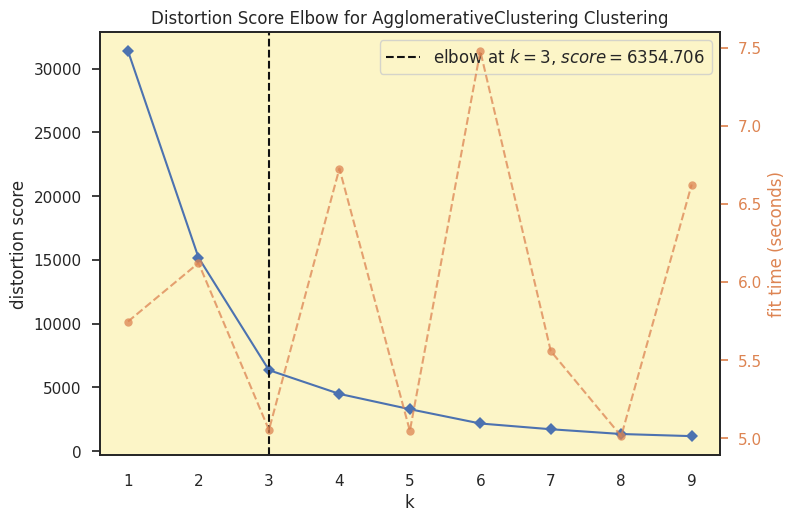

<Axes: title={'center': 'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [131]:
# menentukan jumlah cluster dengan K-Elbow
kelbow = KElbowVisualizer(AgglomerativeClustering(), k=(1,10))
kelbow.fit(x_pca)
kelbow.show()

In [132]:
# menerapkan model setelah seleksi fitur
ac_after = AgglomerativeClustering(n_clusters=3)
y_ac_after = ac_after.fit_predict(x_pca)
y_ac_after

array([1, 1, 2, ..., 1, 2, 2])

In [133]:
# mengevaluasi model setelah seleksi fitur
score_after = silhouette_score(x_pca, y_ac_after)
print('Skor model clustering setelah seleksi fitur: ', score_after)

Skor model clustering setelah seleksi fitur:  0.6084247436027853


In [134]:
# mengubah ukuran cluster menjadi 2 untuk mendapatkan skor maksimal
ac2 = AgglomerativeClustering(n_clusters=2)
y_ac2 = ac2.fit_predict(x_pca)

score2 = silhouette_score(x_pca, y_ac2)
print('Skor model jika cluster berjumlah 2: ', score2)

Skor model jika cluster berjumlah 2:  0.8688692288160477


## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

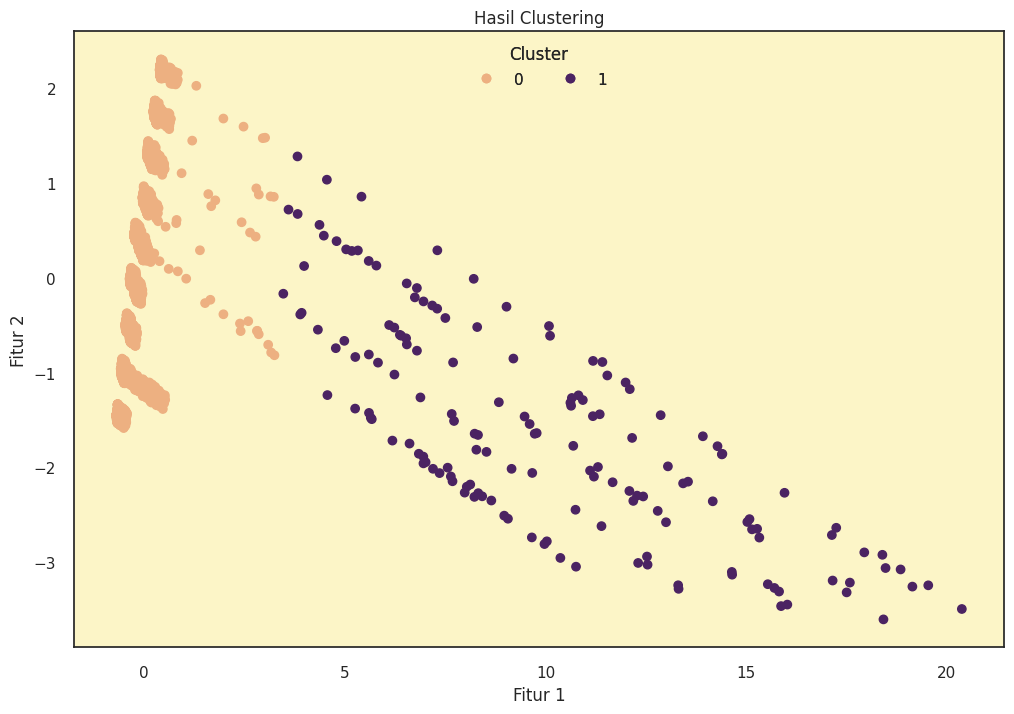

In [203]:
fig, ax = plt.subplots(figsize=(12,8))
sc = ax.scatter(x_pca[:,0], x_pca[:,1], c=y_ac2, cmap='flare')
legend = ax.legend(*sc.legend_elements(), loc="upper center", ncols=2, title="Cluster")
ax.add_artist(legend)
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.title('Hasil Clustering')
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

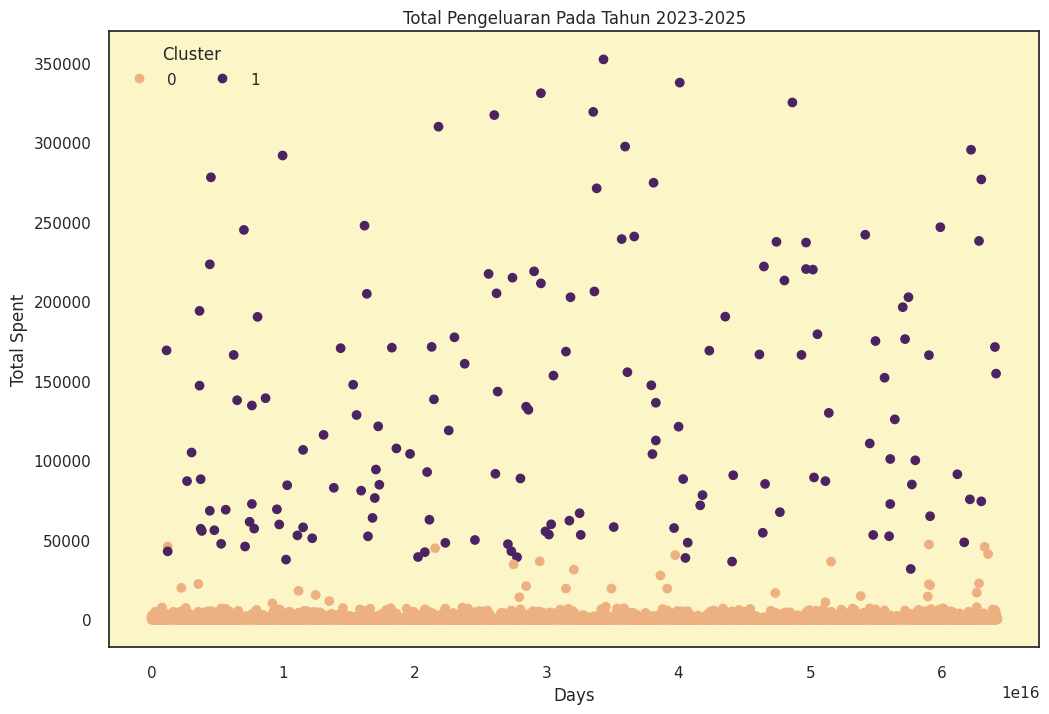

In [197]:
# distribusi data setelah clustering
fig, ax = plt.subplots(figsize=(12,8))
sc = ax.scatter(df_before['Days'], df_before['Total Spent'], c=y_ac2, cmap='flare')
legend = ax.legend(*sc.legend_elements(), loc="upper left", ncols=2, title="Cluster")
plt.xlabel('Days')
plt.ylabel('Total Spent')
plt.title('Total Pengeluaran Pada Tahun 2023-2025')
plt.show()

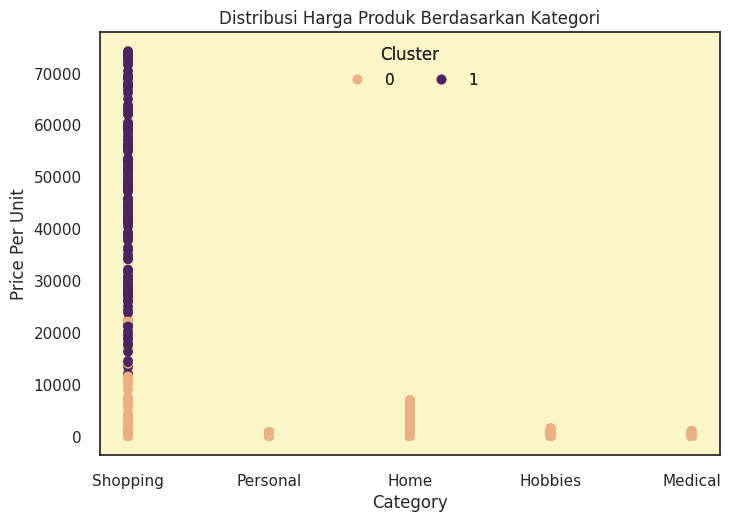

In [205]:
fig, ax = plt.subplots()
sc = ax.scatter(df_before['Category'], df_before['Price Per Unit'], c=y_ac2, cmap='flare')
legend = ax.legend(*sc.legend_elements(), loc="upper center", ncols=2, title="Cluster")
ax.add_artist(legend)
plt.xlabel('Category')
plt.ylabel('Price Per Unit')
plt.title('Distribusi Harga Produk Berdasarkan Kategori')
plt.show()

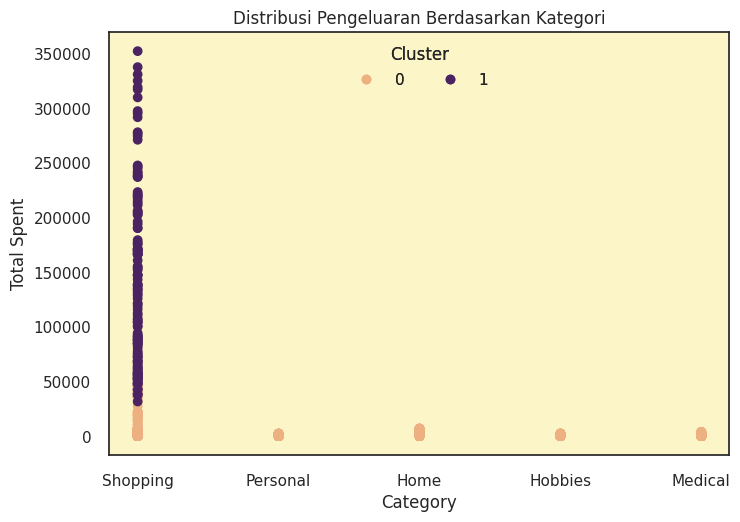

In [213]:
fig, ax = plt.subplots()
sc = ax.scatter(df_before['Category'], df_before['Total Spent'], c=y_ac2, cmap='flare')
legend = ax.legend(*sc.legend_elements(), loc="upper center", ncols=2, title="Cluster")
ax.add_artist(legend)
plt.xlabel('Category')
plt.ylabel('Total Spent')
plt.title('Distribusi Pengeluaran Berdasarkan Kategori')
plt.show()

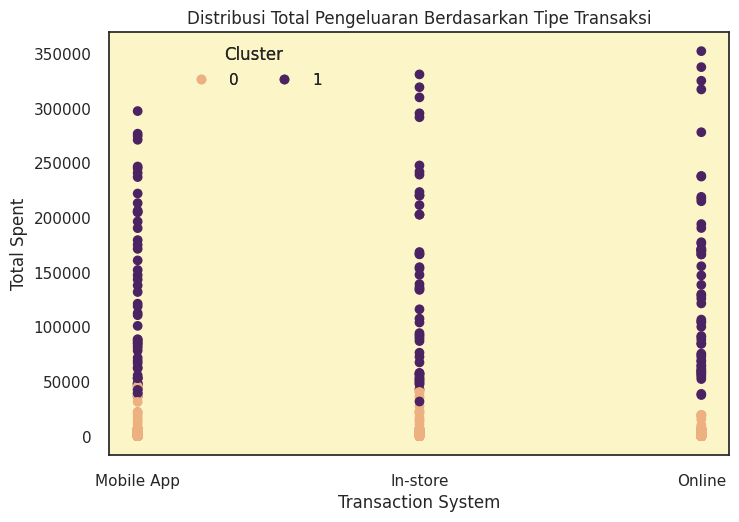

In [207]:
fig, ax = plt.subplots()
sc = ax.scatter(df_before['Location'], df_before['Total Spent'], c=y_ac2, cmap='flare')
legend = ax.legend(*sc.legend_elements(), loc="upper left", ncols=2, title="Cluster", bbox_to_anchor=(0.1, 1))
ax.add_artist(legend)
plt.xlabel('Transaction System')
plt.ylabel('Total Spent')
plt.title('Distribusi Total Pengeluaran Berdasarkan Tipe Transaksi')
plt.show()

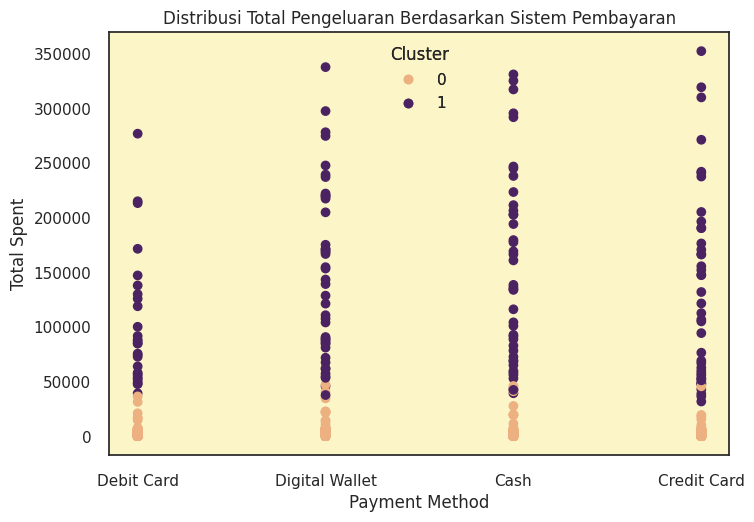

In [208]:
fig, ax = plt.subplots()
sc = ax.scatter(df_before['Payment Method'], df_before['Total Spent'], c=y_ac2, cmap='flare')
legend = ax.legend(*sc.legend_elements(), loc="upper center", title="Cluster")
ax.add_artist(legend)
plt.xlabel('Payment Method')
plt.ylabel('Total Spent')
plt.title('Distribusi Total Pengeluaran Berdasarkan Sistem Pembayaran')
plt.show()

Berdasarkan penyajian data dalam bentuk grafik yang tertera di atas, penyebaran data yang ditangkap oleh model berhasil dipisahkan ke dalam 2 cluster yakni Cluster 0 dan Cluster 1. Kedua cluster ini jika dilihat dari total pengeluaran pada grafik yang tertera dan jika dikelompokkan dalam hirarki sosial maka dapat ditarik kesimpulkan bahwa Cluster pertama terdiri dari masyarakat golongan menengah ke bawah, sedangkan Cluster kedua terdiri dari masyarakat golongan menengah ke atas. Penjelasan untuk tiap cluster di dalam grafik diperinci sebagai berikut:

1. **Cluster 1**: Total pengeluaran pada cluster ini berkisar dari 0-50000 berdasarkan tahun 2023-2025 maupun berdasarkan kategori. Umumnya cluster ini mendistribusikan pengeluarannya ke dalam berbagai kategori secara merata, namun jumlah pengeluarannya di tiap kategori selama tiga tahun memang tidak banyak, maka dari itu cluster ini sangat cocok apabila dikategorikan sebagai golongan menengah ke bawah. Meskipun cluster ini dikategorikan sebagai golongan menengah ke bawah, fakta dalam grafik tidak merendahkan kedudukannya. Dalam grafik metode dan sistem pembayaran, golongan ini masih mendominasi tiap jenisnya. Hal ini menunjukkan bahwa golongan menengah ke bawah juga dapat beradaptasi dengan cepat terhadap kemaujuan zaman.
2. **Cluster 2**: Total pengeluaran pada cluster ini berkisar dari 50000-350000 berdasarkan tahun 2023-2025 maupun berdasarkan kategori. Garis besar yang harus diperhatikan lebih mendalam adalah cluster ini cenderung memusatkan pengeluarannya pada hal yang berkaitan dengan Shopping dalam jumlah yang sangat fantastis. Terlebih lagi dalam metode dan sistem pembayaran pun mereka sangat mendominasi di tiap jenisnya dengan pengeluaran yang terbilang besar bahkan harga per unit yang tidak sedikit. Maka, tidak berlebihan apabila cluster ini dikelompokkan ke dalam golongan menengah ke atas.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [216]:
df['Target'] = y_ac2
df.head()

,Category,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Days,Target
0,4,1,1.28,1.28,2,1,5270400000000000,0
1,3,2,74.69,149.39,2,0,53568000000000000,0
2,1,1,76.06,76.06,3,1,34041600000000000,0
3,0,5,11.24,56.18,0,0,30326400000000000,0
4,3,3,43.71,131.12,2,0,46224000000000000,0


In [217]:
df.to_csv('/content/drive/My Drive/Collabs ML/spent_cluster.csv', index=False)